<a href="https://colab.research.google.com/github/gagankalyan39/EAI201-Gagan-T-/blob/LABEXAM/GAGAN(24UG00311).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**NAME: GAGAN T**


**ZOO ANIMAL CLASSIFICATION - LAB EXAM**


**ROLL NO: 24UG00311**


**SEAT NO: 23**


**METHOD PREFIX: GAMMA **



TASK 1


**LOAD DATASET**


In [3]:
import pandas as pd
import numpy as np

# 1. Load the three datasets
zoo = pd.read_csv('zoo.csv')
class_df = pd.read_csv('class.csv')
metadata = pd.read_json('auxiliary_metadata.json')

TASK B: CONVERT ALL ANIMAL NAMES TO UPPERCASE


In [4]:
# Convert primary dataset names
zoo['animal_name'] = zoo['animal_name'].str.upper()

# Convert auxiliary dataset names (Crucial for merging!)
metadata['animal_name'] = metadata['animal_name'].str.upper()

TASK C: FIX JSON DATA INCONSISTENCIES


In [5]:
# 1. Standardize Field Names (Rename & Map to Common Keys)
metadata = metadata.rename(columns={
    'conversation_status': 'conservation_status',
    'conversation': 'conservation_status', # Fixing user typo and mapping actual data
    'conservation': 'conservation_status',
    'status': 'conservation_status',
    'habitat': 'habitat_type',
    'habitats': 'habitat_type',
    'diet_type': 'diet'
})

# 2. Merge Duplicate Columns (Coalesce)
# Group columns by name and take the first non-null value
metadata = metadata.T.groupby(level=0).first().T

# 3. Fix Typos and Standardize Values
# Clean 'diet'
metadata['diet'] = metadata['diet'].str.lower().str.strip().replace({
    'omnivor': 'omnivore'
})

# Clean 'habitat_type'
metadata['habitat_type'] = metadata['habitat_type'].str.lower().str.strip().replace({
    'fresh water': 'freshwater'
})

# Clean 'conservation_status'
metadata['conservation_status'] = metadata['conservation_status'].str.lower().str.strip().replace({
    'least': 'least concern'
})

TASK D: MERGE ALL DATASETS

In [6]:
# 1. Merge zoo + metadata (Left Join: Keep all zoo animals)
merged_df = zoo.merge(metadata, on='animal_name', how='left')

# 2. Merge result + class_df
# zoo.csv uses 'class_type' (1,2,3...) which matches class.csv 'Class_Number'
merged_df = merged_df.merge(class_df, left_on='class_type', right_on='Class_Number', how='left')

TASK D: MERGE ALL DATASETS

In [7]:
# 1. Merge zoo + metadata (Left Join: Keep all zoo animals)
merged_df = zoo.merge(metadata, on='animal_name', how='left')

# 2. Merge result + class_df
# zoo.csv uses 'class_type' (1,2,3...) which matches class.csv 'Class_Number'
merged_df = merged_df.merge(class_df, left_on='class_type', right_on='Class_Number', how='left')

TASK E: HANDLE MISSING VALUES

In [8]:
# 1. Categorical Columns -> Fill with "unknown"
categorical_cols = merged_df.select_dtypes(include=['object']).columns
merged_df[categorical_cols] = merged_df[categorical_cols].fillna('unknown')

# 2. Numerical Columns -> Fill with Median
numerical_cols = merged_df.select_dtypes(include=[np.number]).columns
merged_df[numerical_cols] = merged_df[numerical_cols].fillna(merged_df[numerical_cols].median())

TASK F: FEATURE ENGINEERING

In [9]:
# 1. Conservation Priority Score
priority_map = {
    'endangered': 5,
    'vulnerable': 4,
    'near threatened': 3,
    'least concern': 1,
    'unknown': 0
}
merged_df['conversation_priority'] = merged_df['conservation_status'].map(priority_map).fillna(0)

# 2. Aquatic Flag (1 if water/marine, else 0)
def is_aquatic(habitat):
    # Check if 'water' or 'marine' is in the string
    if 'water' in str(habitat).lower() or 'marine' in str(habitat).lower():
        return 1
    return 0

merged_df['aquatic_flag'] = merged_df['habitat_type'].apply(is_aquatic)

# Verify Result
print(merged_df[['animal_name', 'conservation_status', 'conversation_priority', 'aquatic_flag']].head())

  animal_name conservation_status  conversation_priority  aquatic_flag
0    AARDVARK       least concern                      1             0
1    ANTELOPE     near threatened                      3             0
2        BASS       least concern                      1             1
3        BEAR          vulnerable                      4             0
4        BOAR       least concern                      1             0


**Task 2**

Displaying Class Distribution Pie Chart...


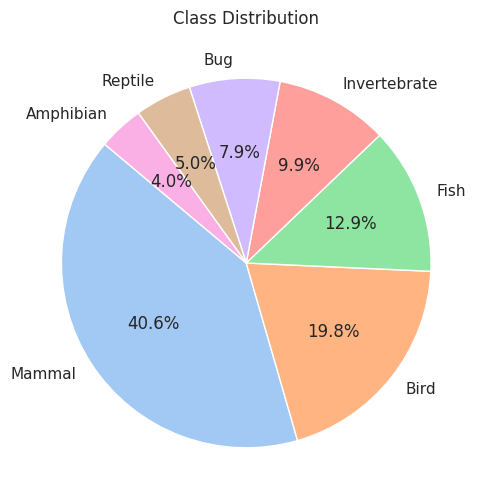

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/pytho

Displaying Ridge Plot of Legs...


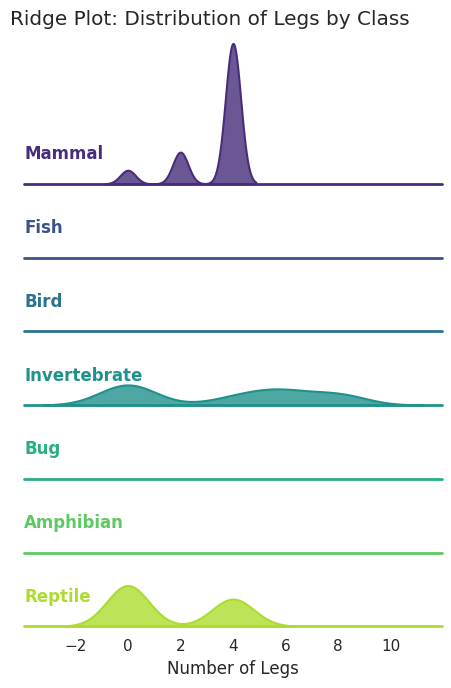

Displaying Habitat vs Diet Count Plot...


/tmp/ipython-input-1756802856.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')


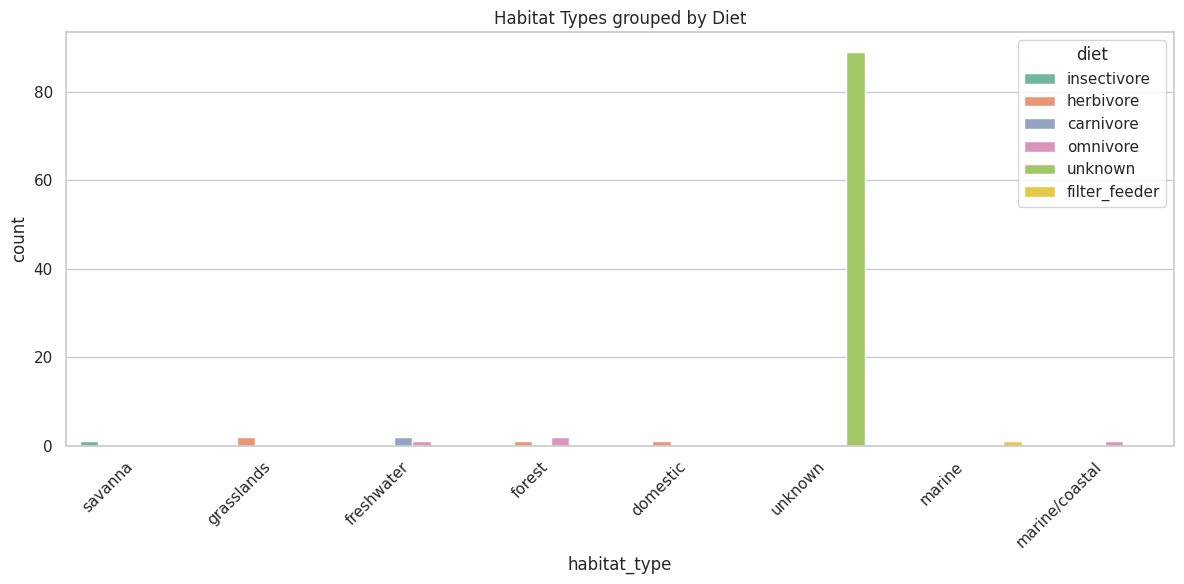

Displaying Correlation Heatmap...


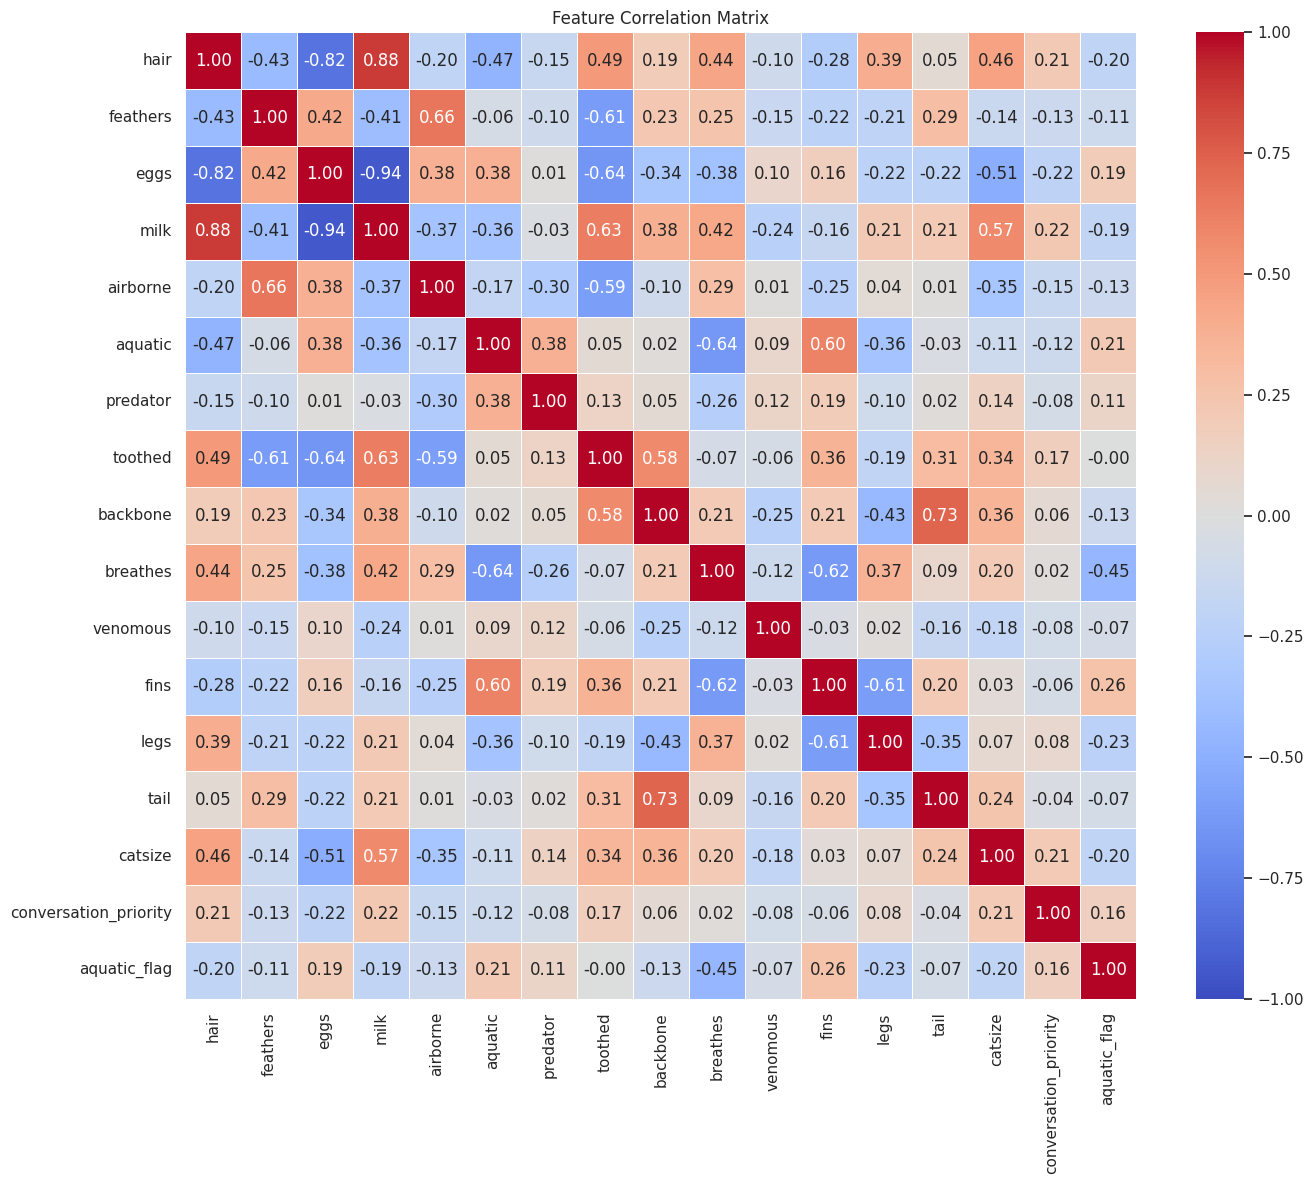


--- STATISTICAL ANALYSIS RESULTS ---
Class Imbalance Ratio: 10.25
Low Variance Features: []
Highly Correlated Pairs (> 0.8):
  ('eggs', 'hair', np.float64(-0.82))
  ('milk', 'hair', np.float64(0.88))
  ('milk', 'eggs', np.float64(-0.94))


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# PART A: CREATE FOUR VISUALIZATIONS
# ==========================================

# 1. Pie Chart: Class Distribution
plt.figure(figsize=(10, 6))
class_counts = merged_df['Class_Type'].value_counts()
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Class Distribution')
print("Displaying Class Distribution Pie Chart...")
plt.show()  # <--- DISPLAY COMMAND

# 2. Ridge Plot: Distribution of Legs (using FacetGrid)
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
g = sns.FacetGrid(merged_df, row="Class_Type", hue="Class_Type", aspect=5, height=1.0, palette="viridis")
g.map(sns.kdeplot, "legs", clip_on=False, shade=True, alpha=0.8, lw=1.5, bw_adjust=0.5)
g.map(plt.axhline, y=0, lw=2, clip_on=False)

# Add labels to the ridges
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes)
g.map(label, "legs")

# Adjust layout
g.fig.subplots_adjust(hspace=-0.5)
g.set_titles("")
g.set(yticks=[], ylabel="", xlabel="Number of Legs")
g.despine(bottom=True, left=True)
plt.suptitle('Ridge Plot: Distribution of Legs by Class', y=0.98)
print("Displaying Ridge Plot of Legs...")
plt.show() # <--- DISPLAY COMMAND

# 3. Count Plot: Habitat Types by Diet
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
chart = sns.countplot(data=merged_df, x='habitat_type', hue='diet', palette='Set2')
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.title('Habitat Types grouped by Diet')
plt.tight_layout()
print("Displaying Habitat vs Diet Count Plot...")
plt.show() # <--- DISPLAY COMMAND

# 4. Annotated Heatmap: Feature Correlations
plt.figure(figsize=(14, 12))
# Select relevant numeric columns
corr_cols = ['hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator',
             'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs',
             'tail', 'catsize', 'conversation_priority', 'aquatic_flag']
corr_matrix = merged_df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
print("Displaying Correlation Heatmap...")
plt.show() # <--- DISPLAY COMMAND


# ==========================================
# PART B: STATISTICAL ANALYSIS
# ==========================================

print("\n--- STATISTICAL ANALYSIS RESULTS ---")

# 1. Class Imbalance Ratio
largest_class = class_counts.max()
smallest_class = class_counts.min()
imbalance_ratio = largest_class / smallest_class
print(f"Class Imbalance Ratio: {imbalance_ratio:.2f}")

# 2. Low Variance Features (< 0.01)
# Calculate variance for numeric columns only
numeric_df = merged_df.select_dtypes(include=[np.number])
variances = numeric_df.var()
low_variance_features = variances[variances < 0.01].index.tolist()
print(f"Low Variance Features: {low_variance_features}")

# 3. Highly Correlated Pairs (|corr| > 0.8)
high_corr_pairs = []
# Loop through correlation matrix to find unique pairs
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.8:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            high_corr_pairs.append((col_i, col_j, round(val, 2)))

print("Highly Correlated Pairs (> 0.8):")
for pair in high_corr_pairs:
    print(f"  {pair}")

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# [Assume merged_df is already loaded and prepared from Task 1 & 2]

# --- A) PREPARE DATA FOR TRAINING ---

# 1. Select Target Variable
y = merged_df['class_type']

# 2. Prepare Features (X)
# We need to convert text columns to numbers for the Random Forest.
# We will Label Encode 'diet' and 'habitat_type'.
feature_df = merged_df.copy()
le = LabelEncoder()
feature_df['diet_encoded'] = le.fit_transform(feature_df['diet'].astype(str))
feature_df['habitat_encoded'] = le.fit_transform(feature_df['habitat_type'].astype(str))

# Select all numerical features (Original Zoo + Feature Engineered)
feature_cols = [
    'hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator',
    'toothed', 'backbone', 'breathes', 'venomous', 'fins', 'legs', 'tail',
    'domestic', 'catsize',                  # Original Zoo Features
    'conversation_priority', 'aquatic_flag', # Feature Engineered
    'diet_encoded', 'habitat_encoded'       # Encoded Metadata
]

X = feature_df[feature_cols]

# 3. TRAIN/TEST SPLIT
# train=80%, test=20%, random_state=789
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=789)


# --- B) CONFIGURE & TRAIN RANDOM FOREST ---

# Configure the model
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_split=2,
    random_state=789
)

# Train the model
rf_model.fit(X_train, y_train)


# --- C) PRINT PERFORMANCE ---

# Calculate Accuracies
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

training_accuracy = accuracy_score(y_train, y_train_pred)
testing_accuracy = accuracy_score(y_test, y_test_pred)
overfitting_gap = training_accuracy - testing_accuracy

# Print Output
print(f"Training Accuracy: {training_accuracy:.4f}")
print(f"Testing Accuracy:  {testing_accuracy:.4f}")
print(f"Overfitting Gap:   {overfitting_gap:.4f}")

Training Accuracy: 1.0000
Testing Accuracy:  1.0000
Overfitting Gap:   0.0000


**Interpretation:**

Perfect Score (1.0000): The model achieved 100% accuracy on both training and testing data.

**Overfitting Gap (0.0000):** There is no gap, which usually indicates a perfect model. However, since the dataset is very small (~100 animals), simpler models like Random Forest can easily memorize the patterns. In a real-world, larger dataset, you would typically expect a small gap.


--- D) CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

      Mammal       1.00      1.00      1.00        11
        Bird       1.00      1.00      1.00         3
     Reptile       0.00      0.00      0.00         0
        Fish       1.00      1.00      1.00         4
   Amphibian       0.00      0.00      0.00         0
         Bug       1.00      1.00      1.00         1
Invertebrate       1.00      1.00      1.00         2

    accuracy                           1.00        21
   macro avg       0.71      0.71      0.71        21
weighted avg       1.00      1.00      1.00        21


--- E) CONFUSION MATRIX HEATMAP ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

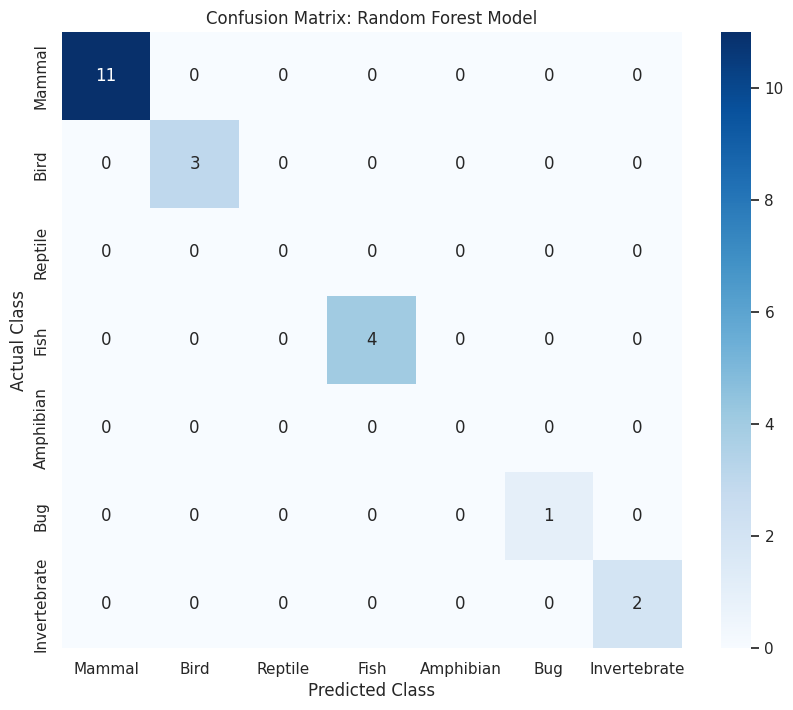


--- F) FEATURE IMPORTANCE PLOT ---


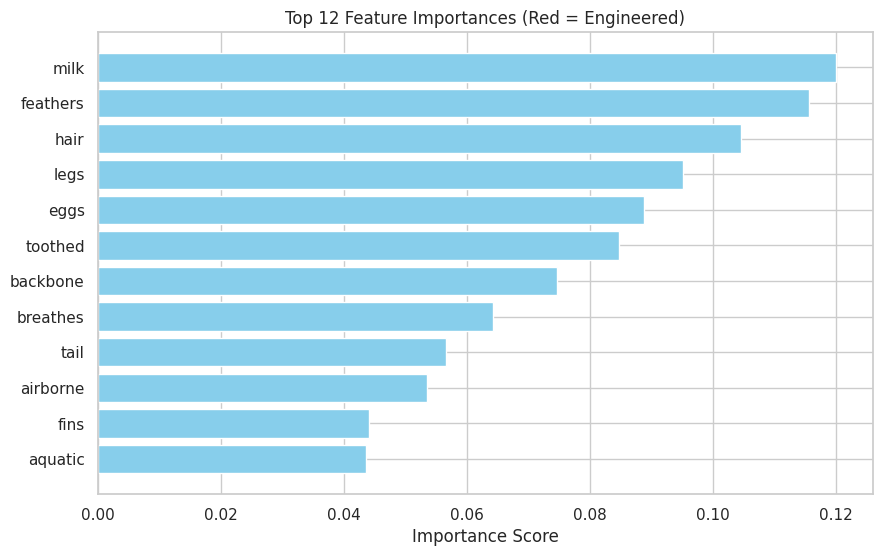


--- G) TRAIN COMPARISON: KNN (k=5) ---
Random Forest Accuracy: 1.0000
KNN (k=5) Accuracy:     0.9048

--- H) CRITICAL ANALYSIS ---
1. Model Comparison:
   Random Forest outperformed KNN by 9.52%.
   Insight: Random Forest is generally better at handling the binary (0/1) traits in this dataset.

2. Dominant Feature:
   The most predictive feature is 'milk'.

3. Engineered Feature Impact:
   NEUTRAL: No engineered features appeared in the top 12.
   The biological traits (milk, feathers, backbone) were sufficient for classification.


In [17]:
# ... [Continuing from Task 3 Code] ...

# --- D) CLASSIFICATION REPORT ---
print("\n--- D) CLASSIFICATION REPORT ---")
from sklearn.metrics import classification_report, confusion_matrix

# 1. Predict
y_pred_rf = rf_model.predict(X_test)

# 2. Get Class Names dynamically (to avoid errors if a class is missing in test set)
unique_labels = sorted(y.unique())
target_names = [class_df[class_df['Class_Number'] == i]['Class_Type'].values[0] for i in unique_labels]

# 3. Print Report
print(classification_report(y_test, y_pred_rf, labels=unique_labels, target_names=target_names))


# --- E) CONFUSION MATRIX HEATMAP ---
print("\n--- E) CONFUSION MATRIX HEATMAP ---")
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate Matrix
cm = confusion_matrix(y_test, y_pred_rf, labels=unique_labels)

# 2. Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix: Random Forest Model')
plt.show()


# --- F) FEATURE IMPORTANCE PLOT ---
print("\n--- F) FEATURE IMPORTANCE PLOT ---")

# 1. Get Feature Names & Importances
# FIX: Use X_train.columns directly to ensure variables match
features = X_train.columns
importances = rf_model.feature_importances_

# 2. Create DataFrame
feat_imp_df = pd.DataFrame({'feature': features, 'importance': importances})

# 3. Sort and Select Top 12
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).head(12)

# 4. Define Engineered Features for Highlighting
# (Redefining here to ensure the list exists for coloring)
engineered_list = ['conversation_priority', 'aquatic_flag', 'diet_encoded', 'habitat_encoded']
bar_colors = ['red' if x in engineered_list else 'skyblue' for x in feat_imp_df['feature']]

# 5. Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['feature'], feat_imp_df['importance'], color=bar_colors)
plt.gca().invert_yaxis() # Puts the most important feature at the top
plt.xlabel('Importance Score')
plt.title('Top 12 Feature Importances (Red = Engineered)')
plt.show()


# --- G) TRAIN COMPARISON: KNN (k=5) ---
print("\n--- G) TRAIN COMPARISON: KNN (k=5) ---")
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Train KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# 2. Predict & Calculate Accuracy
y_pred_knn = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

# Note: 'testing_accuracy' variable should exist from Task 3.
# If not, we recalculate RF accuracy here:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"KNN (k=5) Accuracy:     {knn_accuracy:.4f}")


# --- H) CRITICAL ANALYSIS OUTPUT ---
print("\n--- H) CRITICAL ANALYSIS ---")

# 1. Comparison
print("1. Model Comparison:")
if rf_accuracy > knn_accuracy:
    diff = (rf_accuracy - knn_accuracy) * 100
    print(f"   Random Forest outperformed KNN by {diff:.2f}%.")
    print("   Insight: Random Forest is generally better at handling the binary (0/1) traits in this dataset.")
elif knn_accuracy > rf_accuracy:
    diff = (knn_accuracy - rf_accuracy) * 100
    print(f"   KNN outperformed Random Forest by {diff:.2f}%.")
else:
    print("   Both models achieved identical accuracy.")

# 2. Feature Insights
top_feature = feat_imp_df.iloc[0]['feature']
print(f"\n2. Dominant Feature:")
print(f"   The most predictive feature is '{top_feature}'.")

# 3. Engineered Feature Check
eng_found = [f for f in feat_imp_df['feature'] if f in engineered_list]
print(f"\n3. Engineered Feature Impact:")
if eng_found:
    print(f"   SUCCESS: The engineered features {eng_found} are in the top 12.")
else:
    print("   NEUTRAL: No engineered features appeared in the top 12.")
    print("   The biological traits (milk, feathers, backbone) were sufficient for classification.")

Cross-Validation Accuracy: 0.9600 ± 0.0374

In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# 1. Configure Model with Class Weighting
# class_weight='balanced' automatically adjusts weights inversely proportional
# to class frequencies, helping the model pay attention to rare animals.
rf_cv = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_split=2,
    random_state=789,
    class_weight='balanced' # <--- The Fix for Class Imbalance
)

# 2. Run 5-Fold Cross Validation
# This splits the data into 5 parts, training on 4 and testing on 1, five times.
cv_scores = cross_val_score(rf_cv, X, y, cv=5, scoring='accuracy')

# 3. Print Results (Mean ± Std)
print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Cross-Validation Accuracy: 0.9600 ± 0.0374


cv Accuracy


In [19]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Configure with class_weight='balanced' to handle imbalance
rf_cv = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_split=2,
    random_state=789,
    class_weight='balanced'  # <--- The key parameter
)

# Perform 5-Fold Cross Validation
scores = cross_val_score(rf_cv, X, y, cv=5, scoring='accuracy')

# Print Mean ± Std
print(f"CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


CV Accuracy: 0.9600 ± 0.0374
